In [6]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import copy

In [ ]:
# select the model's folder (and the episode) you are interested into 
folder_dir = './models/example' 
episode = 15001

with open(os.path.join(folder_dir,'params.json'),'r') as fin:
    args = json.load(fin)

In [8]:
args

{'num_pursuers': 1,
 'map_width': 1,
 'map_height': 1,
 'pursuer_speed': 0.0077,
 'evader_speed': 0.0077,
 'pursuer_max_acceleration': 2.827433388230814,
 'evader_max_acceleration': 2.827433388230814,
 'r_min': 0.025,
 'r_shoot': 0.1,
 'dt': 1,
 'beta': 1000,
 'communication_penalty': 1.0,
 'time_penalty': 0.5,
 'hit_boundary_penalty': 10,
 'lat_acceleration_penalty': 0.5,
 'shooting_penalty': 100,
 'distance_penalty': 100,
 'max_steps': 1000,
 'communication': True,
 'smart_e': True,
 'probabilistic': True,
 'lambd': 2,
 'generalization': True,
 'hidden_dim': 256,
 'discount': 0.99,
 'tau': 0.005,
 'policy_noise': 0.2,
 'noise_clip': 0.5,
 'policy_delay': 5,
 'expl_noise': 0.1,
 'replay_buffer_size': 1000000,
 'gae_lambda': 0.95,
 'policy_clip': 0.2,
 'lr': 0.0003,
 'history_len': 1,
 'multiheadPPO': False,
 'PDQN': False,
 'start_time_steps': 15000,
 'max_timesteps': 6000000,
 'batch_size': 32,
 'save_model': True,
 'eval_freq': 250,
 'eval_episodes': 50,
 'seed': 3,
 'load_seed': 1,

## Setup

In [9]:
from environments.rich_env_tfeats import DifferentialGameEnvironment as SmartsEnvTfeats
# Initialize environment
env_kwargs = {
    "num_pursuers": args['num_pursuers'],
    "map_size": (args['map_width'], args['map_height']),
    "pursuer_speed": args['pursuer_speed'],
    "evader_speed": args['evader_speed'],
    "pursuer_max_acceleration": args['pursuer_max_acceleration'],
    "evader_max_acceleration": args['evader_max_acceleration'],
    "r_min": args.get('r_min',0.025),
    "dt": args['dt'],
    "beta": args['beta'],
    "communication_penalty": args['communication_penalty'],
    "time_penalty": args['time_penalty'],
    "hit_boundary_penalty": args['hit_boundary_penalty'],
    "max_steps": args['max_steps'],
    "r_shoot": args['r_shoot'],
    'random_communication': args['random_communication'],
    'random_communication_th': args['random_communication_th'],
    'communication_period': args.get('communication_period',0),
    'noise_std': args.get('noise_std',0),
}

env = SmartsEnvTfeats(**env_kwargs) 


In [10]:
env._get_evader_state(env._get_state()), env._get_pursuer_state(env._get_state())

((array([ 0.51208692,  0.79846703,  1.52023478,  0.02122279,  2.82743339,
          0.00896646, -0.30579241, -0.59682632, -0.01185216,  0.        ,
          0.30592384,  0.025     ,  0.1       ,  0.        ,  0.        ]),
  [],
  []),
 (array([ 0.52105339,  0.49267462,  0.92340846,  0.00937063,  2.82743339,
         -0.00896646,  0.30579241,  0.59682632,  0.01185216,  0.        ,
          0.30592384,  0.025     ,  0.1       ,  0.        ,  0.        ]),
  [],
  []))

In [11]:
from mediators.DummyMediator import DummyMediator
from mediators.SelfSupervisedStateMediator import SelfSupervisedStateMediator

In [12]:
args.get('use_LSTM_p', True), args.get('use_LSTM_e', True), args['opponent_modelling_p'],args['opponent_modelling_e']

(True, True, True, True)

In [13]:
from model.PursuerAgent_MHPPO import PursuerAgent_MHPPO
from model.StateThinkingPursuer_MHPPO import StateThinkingPursuerAgent_MHPPO
from model.PursuerAgent_PDQN import PursuerAgent_PDQN
from model.StateThinkingPursuerAgent_PDQN import StateThinkingPursuerAgent_PDQN
from model.StateThinkingPursuer import StateThinkingPursuerAgent
# from model.StateThinkingPursuer_noLSTM import StateThinkingPursuerAgent
from model.PursuerAgent import PursuerAgent
from model.StateThinkingPursuer_noLSTM import StateThinkingPursuerAgent as StateThinkingPursuerAgent_noLSTM
from model.PursuerAgent_HyAR import PursuerAgent_HyAR
from model.StateThinkingPursuer_LIAM import StateThinkingPursuerAgentLIAM


if args['opponent_modelling_p']:
    state_dim = 19
    action_dim = 1
    model_kwargs = {
        "state_dim": state_dim,
        "action_dim": action_dim,
        "max_action": args['pursuer_max_acceleration'],
        "hidden_dim": args['hidden_dim'],
        "discount": args['discount'],
        "tau": args['tau'],
        "policy_noise": args['policy_noise'],
        "noise_clip": args['noise_clip'],
        "policy_delay": args['policy_delay'],
        "expl_noise": args['expl_noise'],
        "gae_lambda": args['gae_lambda'],
        "policy_clip": args['policy_clip'],
        "alpha": args['lr'],
        "history_len": args['history_len'],
        "replay_buffer_size": args['replay_buffer_size'],
        "batch_size": args['batch_size']
    }

    pursuer_model_kwargs = copy.deepcopy(model_kwargs)
    
    pursuer_mediator = SelfSupervisedStateMediator(opponent='evader')
    if args['multiheadPPO']:
        pursuer = StateThinkingPursuerAgent_MHPPO(**pursuer_model_kwargs) 
    elif args.get('LIAM',False):
        pursuer = StateThinkingPursuerAgentLIAM(**pursuer_model_kwargs)
    elif args.get('PDQN',False):
        pursuer = StateThinkingPursuerAgent_PDQN(**pursuer_model_kwargs)  # StateThinkingPursuerAgent_PDQN
    elif not args.get('use_LSTM_p',True):
        pursuer = StateThinkingPursuerAgent_noLSTM(**pursuer_model_kwargs)
    else:
        pursuer = StateThinkingPursuerAgent(**pursuer_model_kwargs)
else:
    state_dim = 15
    action_dim = 1
    model_kwargs = {
        "state_dim": state_dim,
        "action_dim": action_dim,
        "max_action": args['pursuer_max_acceleration'],
        "hidden_dim": args['hidden_dim'],
        "discount": args['discount'],
        "tau": args['tau'],
        "policy_noise": args['policy_noise'],
        "noise_clip": args['noise_clip'],
        "policy_delay": args['policy_delay'],
        "expl_noise": args['expl_noise'],
        "gae_lambda": args['gae_lambda'],
        "policy_clip": args['policy_clip'],
        "alpha": args['lr'],
        "history_len": args['history_len'],
        "replay_buffer_size": args['replay_buffer_size'],
        "batch_size": args['batch_size']
    }

    pursuer_model_kwargs = copy.deepcopy(model_kwargs)
    if args['multiheadPPO']:
        pursuer = PursuerAgent_MHPPO(**pursuer_model_kwargs)
    elif args['PDQN']:
        pursuer = PursuerAgent_PDQN(state_dim,args['pursuer_max_acceleration'], args['cuda']) #
    elif args.get('HyAR',False):
        pursuer = PursuerAgent_HyAR(**pursuer_model_kwargs)
    else:
        pursuer = PursuerAgent(**pursuer_model_kwargs)
    pursuer_mediator = DummyMediator()
    
pursuer_filename = os.path.join(folder_dir,str(episode), 'pursuer')
pursuer.load(filename=pursuer_filename)
pursuer


DEBUG - actor PPO =  349954
DEBUG - critic PPO =  349697
DEBUG - actor TD3 =  415489
DEBUG - critic TD3 =  831490
DEBUG - actor Opponent TD3 =  416260
DEBUG - critic Opponent TD3 =  833026


In [14]:
from model.StateThinkingEvader import StateThinkingEvaderAgent
# from model.StateThinkingEvader_noLSTM import StateThinkingEvaderAgent
from model.EvaderAgent import EvaderAgent
from model.StateThinkingEvader_noLSTM import StateThinkingEvaderAgent as StateThinkingEvaderAgent_noLSTM
from model.EvaderAgent_MHPPO import EvaderAgent_MHPPO
from model.StateThinkingEvader_LIAM import StateThinkingEvaderAgentLIAM

if args['opponent_modelling_e']:
    state_dim = 19
    action_dim = 1
    model_kwargs = {
        "state_dim": state_dim,
        "action_dim": action_dim,
        "max_action": args['pursuer_max_acceleration'],
        "hidden_dim": args['hidden_dim'],
        "discount": args['discount'],
        "tau": args['tau'],
        "policy_noise": args['policy_noise'],
        "noise_clip": args['noise_clip'],
        "policy_delay": args['policy_delay'],
        "expl_noise": args['expl_noise'],
        "history_len": args['history_len'],
        "replay_buffer_size": args['replay_buffer_size'],
        "batch_size": args['batch_size']
    }

    evader_model_kwargs = copy.deepcopy(model_kwargs)
    if args.get('Evader_LIAM', False):
        evader = StateThinkingEvaderAgentLIAM(**evader_model_kwargs)
    else:
        if args.get('use_LSTM_e',True):
            evader = StateThinkingEvaderAgent(**evader_model_kwargs)
        else:
            evader = StateThinkingEvaderAgent_noLSTM(**evader_model_kwargs) #
    
    evader_mediator = SelfSupervisedStateMediator(opponent='pursuer') # DummyMediator()

else:

    state_dim = 13
    action_dim = 1

    model_kwargs = {
        "state_dim": state_dim,
        "action_dim": action_dim,
        "max_action": args['pursuer_max_acceleration'],
        "hidden_dim": args['hidden_dim'],
        "discount": args['discount'],
        "tau": args['tau'],
        "policy_noise": args['policy_noise'],
        "noise_clip": args['noise_clip'],
        "policy_delay": args['policy_delay'],
        "expl_noise": args['expl_noise'],
        "history_len": args['history_len'],
        "replay_buffer_size": args['replay_buffer_size'],
        "batch_size": args['batch_size']
    }

    evader_model_kwargs = copy.deepcopy(model_kwargs)
    evader = EvaderAgent(**evader_model_kwargs)
    evader_mediator = DummyMediator()

evader_filename = os.path.join(folder_dir,str(episode), 'evader')
evader.load(filename=evader_filename)
evader

DEBUG - actor TD3 =  415489
DEBUG - critic TD3 =  831490
DEBUG - actor Opponent TD3 =  416260
DEBUG - critic Opponent TD3 =  833026


In [15]:
pursuer, evader, evader_mediator, pursuer_mediator

(<model.StateThinkingPursuer.StateThinkingPursuerAgent at 0x7f890f320e80>,
 <mediators.SelfSupervisedStateMediator.SelfSupervisedStateMediator at 0x7f890f321240>)

## Run evaluation

In [16]:
args['opponent_modelling_p'], args['opponent_modelling_e'], args['use_LSTM_p'], args['use_LSTM_e']

(True, True, True, True)

In [17]:
from mediators.DummyMediator import DummyMediator
from mediators.SelfSupervisedStateMediator import SelfSupervisedStateMediator
from train.train_rich import eval_policy

avg_reward, meta = eval_policy(pursuer, evader, 
                               pursuer_mediator, evader_mediator, 
                               env, 
                               eval_episodes=10, max_steps=1_000, eval = True, 
                               opponent_modelling_p=args['opponent_modelling_p'], opponent_modelling_e=args['opponent_modelling_e'],
                               verbose=False,
                               is_pdqn=args.get('PDQN',False),
                               HyAR=args.get('HyAR',False), MPDQN=args.get('MPDQN',False),
                               is_multihead_e=args.get('Evader_MHPPO',False),)


100%|██████████| 10/10 [00:03<00:00,  2.57it/s]

---------------------------------------
Evaluation over 10 episodes: 646.187
---------------------------------------


In [18]:
from utils.evaluation import aggregate_results
df_results = aggregate_results(meta)
df_results.head(1)

,n_steps,truncation,termination,lambd,rews_p,rews_e,episode,p_movement,p_communication,e_movement,...,a_e,dist,r_min,r_shoot,T_since_last_comm,T_last_comm,x_e_pred,y_e_pred,psi_e_pred,sigma
0,7,False,True,3.87282,-1.43312,-3.400287,0,0.333471,0,0.803056,...,2.827433,0.262043,0.025,0.1,0.001,0.0,0.436571,0.680276,1.935167,1.529935


In [19]:
df_results.groupby('episode').termination.max().sum()

7

In [20]:
df_results.termination.value_counts()


termination
True     673
False    560
Name: count, dtype: int64

## Plot example

In [21]:
df_results.columns

Index(['n_steps', 'truncation', 'termination', 'lambd', 'rews_p', 'rews_e',
       'episode', 'p_movement', 'p_communication', 'e_movement', 'x_p', 'y_p',
       'psi_p', 'v_p', 'a_p', 'x_e', 'y_e', 'psi_e', 'v_e', 'a_e', 'dist',
       'r_min', 'r_shoot', 'T_since_last_comm', 'T_last_comm', 'x_e_pred',
       'y_e_pred', 'psi_e_pred', 'sigma'],
      dtype='object')

Episode: 0, Termination:  7 Truncation:  False
v_p: 0.011069421526722733, v_e: 0.03960544603472067, speed_ratio: 0.27949240912521395


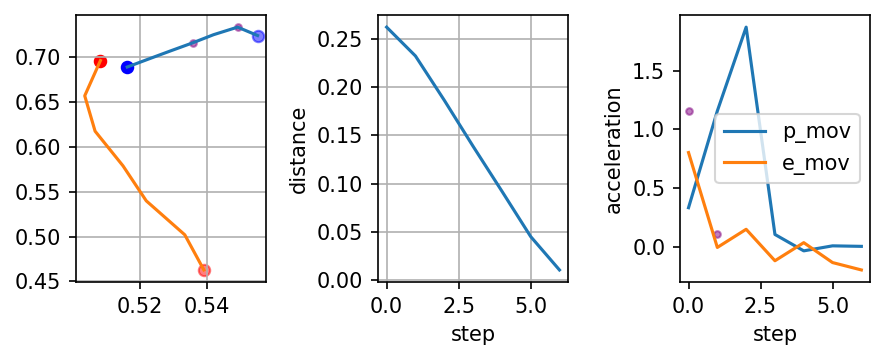

Episode: 1, Termination:  27 Truncation:  False
v_p: 0.009134203627608067, v_e: 0.013223466344171209, speed_ratio: 0.6907571275087296


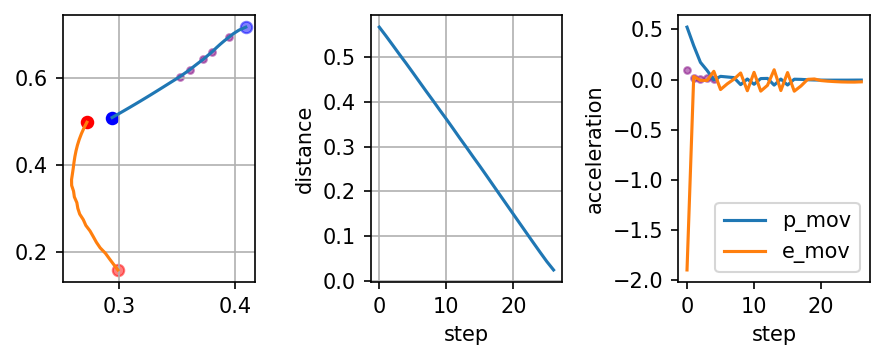

Episode: 2, Termination:  117 Truncation:  False
v_p: 0.009275794482091388, v_e: 0.023330077277329202, speed_ratio: 0.3975895309658944


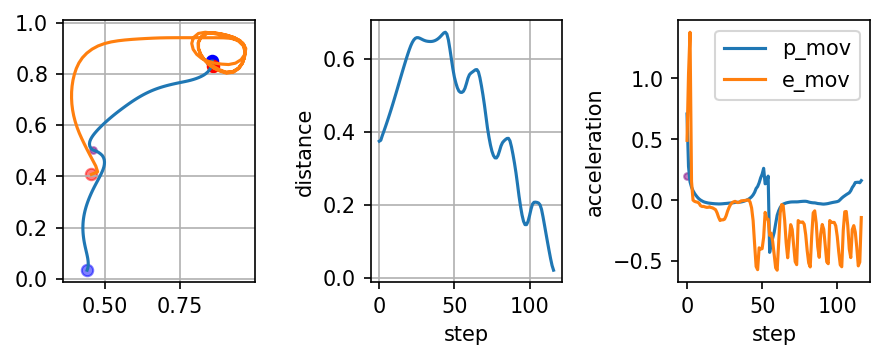

Episode: 3, Termination:  212 Truncation:  False
v_p: 0.00866700689057154, v_e: 0.00787178495515477, speed_ratio: 1.1010218063561334


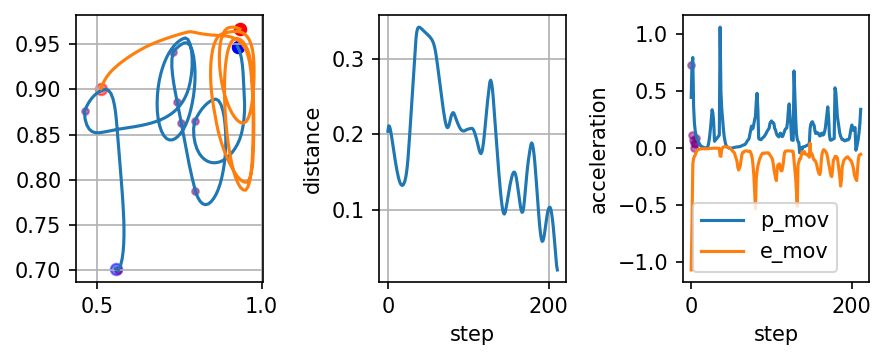

Episode: 4, Termination:  22 Truncation:  False
v_p: 0.015217313301777061, v_e: 0.0018914815372309635, speed_ratio: 8.045182044998686


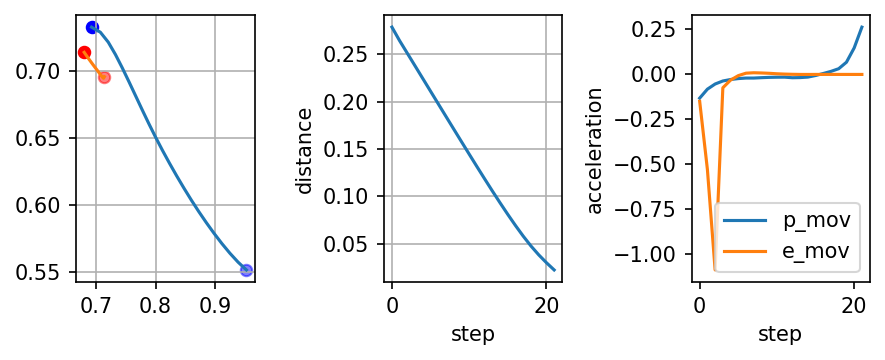

Episode: 5, Termination:  71 Truncation:  False
v_p: 0.013597490494898432, v_e: 0.028851565333188035, speed_ratio: 0.4712912570902072


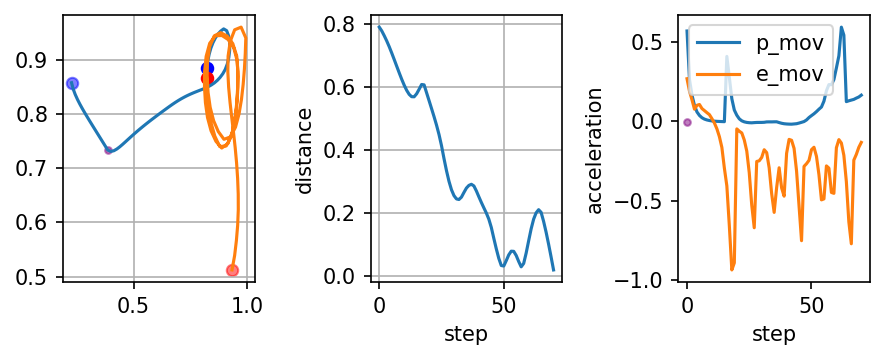

Episode: 6, Termination:  217 Truncation:  False
v_p: 0.011779593688884727, v_e: 0.020418146603796098, speed_ratio: 0.5769178720018932


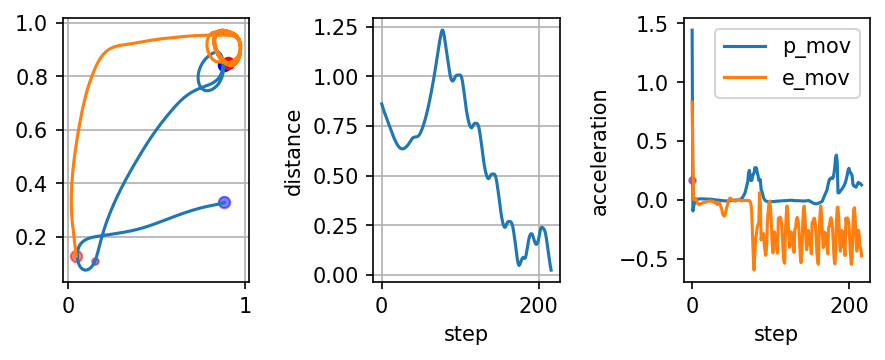

Episode: 7, Termination:  185 Truncation:  True
v_p: 0.011558627570181522, v_e: 0.004403830401426516, speed_ratio: 2.624675910870087


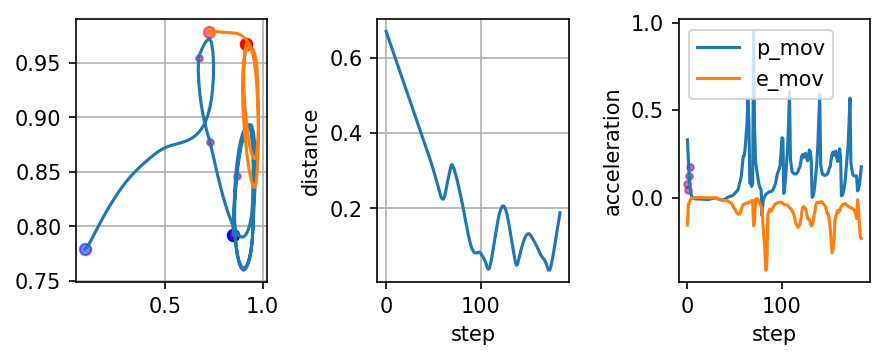

Episode: 8, Termination:  198 Truncation:  True
v_p: 0.011014609900852177, v_e: 0.01838525975825192, speed_ratio: 0.5991000424080738


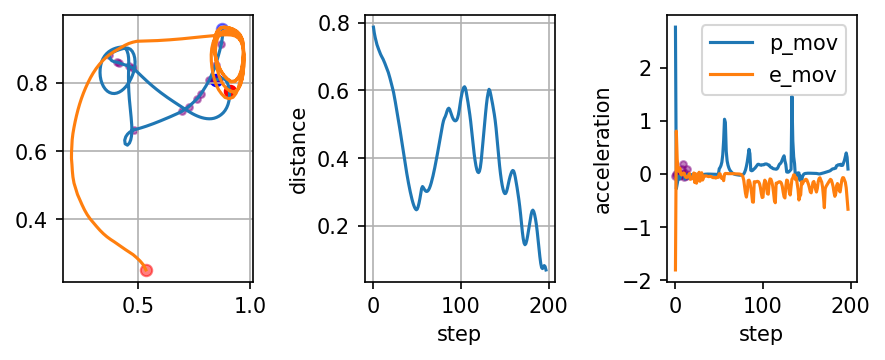

Episode: 9, Termination:  177 Truncation:  True
v_p: 0.010922512989930484, v_e: 0.011660815414767767, speed_ratio: 0.936685180360349


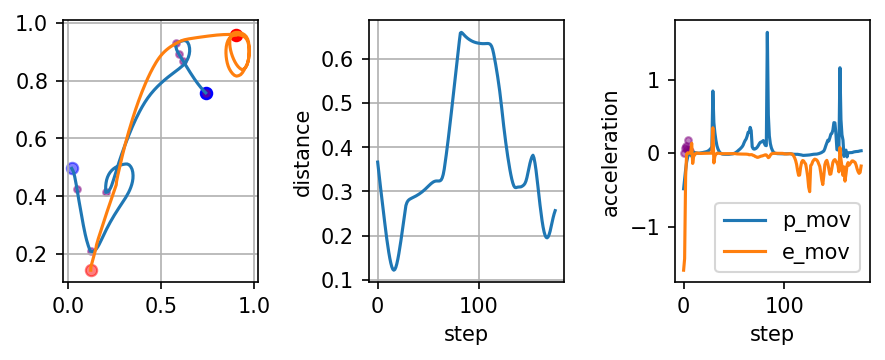

In [22]:
for episode_id in range(0,10):
    
    df_states = df_results[df_results.episode==episode_id]
    
    fig, ax = plt.subplots(1 ,3,figsize=(6,2.5),dpi=150)
    
    ax[0].plot(df_states.x_p, df_states.y_p,label='pursuer')
    ax[0].plot(df_states.x_e, df_states.y_e,label='evader')
    # ax[0].plot(df_states.x_e_pred, df_states.y_e_pred,label='evader_pred')
    
    ax[2].plot(list(range(len(df_states))),df_states.p_movement, label = 'p_mov')
    ax[2].plot(list(range(len(df_states))),df_states.e_movement, label = 'e_mov')
    ax[2].scatter(list(range(len(df_states[df_states.p_communication==1]))),df_states[df_states.p_communication==1].p_movement,s=10,label=None, alpha = 0.5,color='purple')
    
    #ax[2].plot(list(range(len(df_states))),df_states.psi_e, label = 'e_mov')
    
    # ax[0].legend()
    
    ax[0].scatter(df_states.x_p.iloc[0],df_states.y_p.iloc[0],s=30,label='p_start', alpha = 0.5, color = 'blue')
    ax[0].scatter(df_states.x_p.iloc[-1],df_states.y_p.iloc[-1],s=30,label='p_end', color = 'blue')
    
    ax[0].scatter(df_states.x_e.iloc[0],df_states.y_e.iloc[0],s=30,label='e_start', alpha = 0.5,color='red')
    ax[0].scatter(df_states.x_e.iloc[-1],df_states.y_e.iloc[-1],s=30,label='e_end', color='red')
    
    ax[0].scatter(df_states[df_states.p_communication==1].x_p,df_states[df_states.p_communication==1].y_p,s=10,label=None, alpha = 0.5,color='purple')
    
    
    ax[1].plot(list(range(len(df_states))), df_states.dist)
    
    ax[0].grid()
    ax[1].grid()
    
    ax[1].set_ylabel('distance')
    ax[1].set_xlabel('step')
    
    
    ax[2].set_xlabel('step')
    ax[2].set_ylabel('acceleration')
    
    ax[2].legend()
    try:
        print(f'Episode: {episode_id}, Termination: ', len(df_states), 'Truncation: ', df_states.truncation.iloc[episode_id])
        print(f'v_p: {str(df_states.v_p.iloc[0])}, v_e: {df_states.v_e.iloc[0]}, speed_ratio: {df_states.v_p.iloc[0] / df_states.v_e.iloc[0]}')
    except:
        pass
    
    plt.tight_layout()
    plt.show()


In [24]:
episode_id = 9

df_states = df_results[df_results.episode==episode_id]

# df_states.to_csv('example_4.csv', index=False)

df_toplot = df_states[['p_communication','x_p','y_p','x_e','y_e','dist']]
df_toplot
df_toplot.reset_index(drop=True, inplace=True)



/tmp/ipykernel_667781/1687975985.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


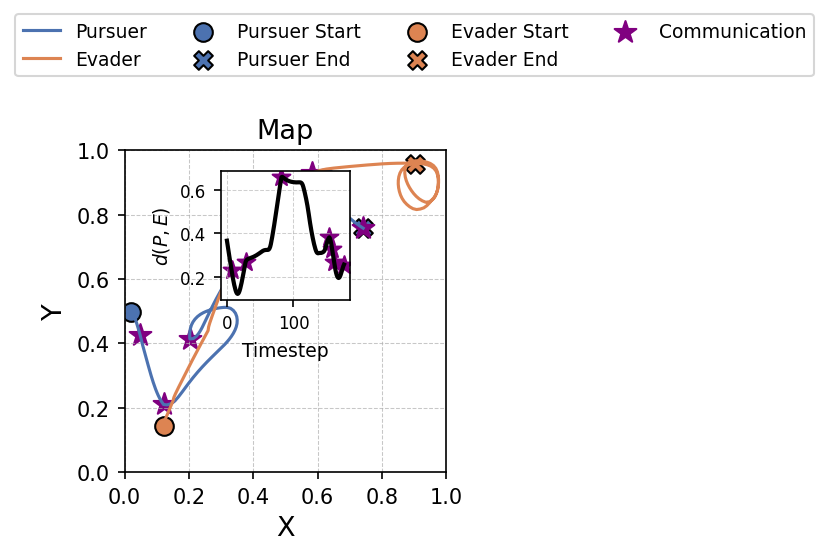

In [25]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Optional: Seaborn color palette
colors = sns.color_palette('deep').as_hex()

# Create main figure and axis
fig, ax1 = plt.subplots(figsize=(6, 4), dpi=150)

# === Main Plot: Map with Trajectories ===

# Plot trajectories
ax1.plot(df_toplot['x_p'], df_toplot['y_p'], color=colors[0], lw=1.5, label='Pursuer')
ax1.plot(df_toplot['x_e'], df_toplot['y_e'], color=colors[1], lw=1.5, label='Evader')

# Start and end points
ax1.scatter(df_toplot['x_p'].iloc[0], df_toplot['y_p'].iloc[0], color=colors[0],
            edgecolor='black', marker='o', s=80, label='Pursuer Start')
ax1.scatter(df_toplot['x_p'].iloc[-1], df_toplot['y_p'].iloc[-1], color=colors[0],
            edgecolor='black', marker='X', s=80, label='Pursuer End')

ax1.scatter(df_toplot['x_e'].iloc[0], df_toplot['y_e'].iloc[0], color=colors[1],
            edgecolor='black', marker='o', s=80, label='Evader Start')
ax1.scatter(df_toplot['x_e'].iloc[-1], df_toplot['y_e'].iloc[-1], color=colors[1],
            edgecolor='black', marker='X', s=80, label='Evader End')

# Communication points
comm_idx = df_toplot['p_communication'] == 1
ax1.scatter(df_toplot.loc[comm_idx, 'x_p'],
            df_toplot.loc[comm_idx, 'y_p'],
            color='purple', marker='*', s=120, label='Communication')

# Set axis properties
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.0])
ax1.set_xlabel('X',fontsize=13)
ax1.set_ylabel('Y',fontsize=13)
ax1.set_title('Map',fontsize=13)
ax1.set_aspect('equal')  # Ensure square shape
ax1.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

# === Inset Plot: Distance over Time ===

ax_inset = inset_axes(ax1, width="40%", height="40%", loc='upper center', borderpad=1)

# Plot distance
ax_inset.plot(df_toplot.index, df_toplot['dist'], color='black', linewidth=2)

# Communication points in distance plot
ax_inset.scatter(df_toplot.loc[comm_idx].index,
                 df_toplot.loc[comm_idx, 'dist'],
                 color='purple', marker='*', s=80)

# Labels, ticks, and grid for inset
ax_inset.set_xlabel('Timestep', fontsize=9)
ax_inset.set_ylabel(r'$d(P,E)$', fontsize=9)
ax_inset.tick_params(labelsize=8)
ax_inset.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)
# ax_inset.set_title(r'$d(P,E)$', fontsize=8)

ax1.legend(loc='lower center', bbox_to_anchor=(0.9, 1.2),
          ncol=4, frameon=True, fontsize=9)

plt.tight_layout()
# plt.savefig('example_4.pdf', bbox_inches='tight')
